# Task 1 v8 - Segment-Focused SEC-BERT + Six-Stream Ensemble

This is the next experiment after v7.

Main idea: train one more SEC-BERT model with a more segment-focused input:

`[SEG] SegmentName SegmentName [DESC] SegmentDescription [PROFILE_SHORT] first ~140 words of LongProfile`

Then ensemble it with your current best streams:

- DeBERTa v3
- SEC-BERT v5
- combined SVC
- segment-only SVC
- profile-only SVC
- segment-focused SEC-BERT v8

No task 1 CSV leakage tricks or external labels. This is still using only the provided task 1 fields.


In [1]:
from pathlib import Path
import gc
import itertools
import re
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch
import torch.nn as nn
from scipy.special import log_softmax
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)

DATA_PATH = Path("task1_gecs_classification_final.csv")
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

TARGET_COL = "MstarGlobal"
RANDOM_STATE = 42
TEST_SIZE = 0.15
VAL_SIZE = 0.15
EPS = 1e-12

V3_PROBS = MODEL_DIR / "task1_v3_deberta_mt_probs_cont.npz"
if not V3_PROBS.exists():
    V3_PROBS = MODEL_DIR / "task1_v3_deberta_mt_probs.npz"
V5_PROBS = MODEL_DIR / "task1_v5_secbert_mt_probs.npz"
V5_ARTIFACT = MODEL_DIR / "task1_v5_artifact.joblib"
V7_ARTIFACT = MODEL_DIR / "task1_v7_segment_profile_ensemble.joblib"
BGE_CACHE = MODEL_DIR / "task1_BAAI_bge-large-en-v1.5_row_embeddings.npz"
V8_PROBS = MODEL_DIR / "task1_v8_segfocus_secbert_probs.npz"
V8_STATE = MODEL_DIR / "task1_v8_segfocus_secbert_best_state.pt"

# Set this False after the model has been trained once.
RUN_SEGFOCUS_BERT = True

BERT_MODEL_NAME = "nlpaueb/sec-bert-base"
BERT_MAX_LEN = 384
BERT_TRAIN_BS = 4
BERT_EVAL_BS = 8
BERT_GRAD_ACCUM = 4
BERT_EPOCHS = 7
BERT_LR = 2e-5
BERT_WD = 0.01
BERT_WARMUP_RATIO = 0.06
BERT_LABEL_SMOOTHING = 0.02
BERT_CLASS_WEIGHT_POWER = 0.30
BERT_AUX_W_SECTOR = 0.15
BERT_AUX_W_GROUP = 0.20
BERT_DROPOUT = 0.10
BERT_EARLY_STOP = 2

for p in [DATA_PATH, V3_PROBS, V5_PROBS, V5_ARTIFACT, V7_ARTIFACT, BGE_CACHE]:
    print(f"{p}: {'OK' if p.exists() else 'MISSING'}")


c:\Users\shami\anaconda3\envs\vsc\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


task1_gecs_classification_final.csv: OK
models\task1_v3_deberta_mt_probs_cont.npz: OK
models\task1_v5_secbert_mt_probs.npz: OK
models\task1_v5_artifact.joblib: OK
models\task1_v7_segment_profile_ensemble.joblib: OK
models\task1_BAAI_bge-large-en-v1.5_row_embeddings.npz: OK


## 1. Load data and reproduce the v5/v7 split


In [2]:
df = pd.read_csv(DATA_PATH)
df[TARGET_COL] = df[TARGET_COL].astype(str)
df["sector"] = df[TARGET_COL].str[:3]
df["group"] = df[TARGET_COL].str[:5]

idx = np.arange(len(df))
y_full = df[TARGET_COL].values
train_val_idx, test_idx = train_test_split(
    idx, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_full
)
val_frac = VAL_SIZE / (1.0 - TEST_SIZE)
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=val_frac, random_state=RANDOM_STATE, stratify=y_full[train_val_idx]
)

y_train = df.loc[train_idx, TARGET_COL].astype(str).reset_index(drop=True)
y_val = df.loc[val_idx, TARGET_COL].astype(str).reset_index(drop=True)
y_test = df.loc[test_idx, TARGET_COL].astype(str).reset_index(drop=True)
y_val_arr = y_val.to_numpy()
y_test_arr = y_test.to_numpy()

print(f"Rows: {len(df):,}")
print(f"Train/Val/Test: {len(train_idx):,} / {len(val_idx):,} / {len(test_idx):,}")
print(f"Leaves: {df[TARGET_COL].nunique()}  sectors: {df['sector'].nunique()}  groups: {df['group'].nunique()}")


Rows: 53,585
Train/Val/Test: 37,509 / 8,038 / 8,038
Leaves: 145  sectors: 11  groups: 55


## 2. Light raw text for segment-focused SEC-BERT


In [3]:
URL_RE = re.compile(r"http\S+|www\.\S+")
MULTI_SPACE_RE = re.compile(r"\s+")

def light_clean(s):
    if not isinstance(s, str) or not s:
        return ""
    s = s.lower()
    s = URL_RE.sub(" ", s)
    return MULTI_SPACE_RE.sub(" ", s).strip()

def first_words(s, n=140):
    toks = str(s).split()
    return " ".join(toks[:n])

t0 = time.time()
df["seg_name_raw"] = df["SegmentName"].fillna("").map(light_clean)
df["seg_desc_raw"] = df["SegmentDescription"].fillna("").map(light_clean)
df["long_profile_raw"] = df["LongProfile"].fillna("").map(light_clean)
df["seg_desc_raw"] = df["seg_desc_raw"].mask(df["seg_desc_raw"].eq(""), df["seg_name_raw"])
df["seg_name_raw"] = df["seg_name_raw"].mask(df["seg_name_raw"].eq(""), "unknown segment")
df["seg_desc_raw"] = df["seg_desc_raw"].mask(df["seg_desc_raw"].eq(""), "unknown segment")
df["long_profile_short"] = df["long_profile_raw"].map(lambda x: first_words(x, 140))
df["long_profile_short"] = df["long_profile_short"].mask(df["long_profile_short"].eq(""), "unknown profile")
print(f"Raw text prep done in {time.time() - t0:.1f}s")

def build_segfocus_text(row_idx):
    sn = df.loc[row_idx, "seg_name_raw"].astype(str)
    sd = df.loc[row_idx, "seg_desc_raw"].astype(str)
    lp = df.loc[row_idx, "long_profile_short"].astype(str)
    return ("[SEG] " + sn + " " + sn + " [DESC] " + sd + " [PROFILE_SHORT] " + lp).tolist()

print(build_segfocus_text(train_idx[:1])[0][:500])


Raw text prep done in 2.3s
[SEG] retail banking retail banking [DESC] retail banking comprises of lending of funds and other banking services to any legal person including small business customers, on the basis of the borrower, nature of the product, granularity of the exposure and quantum thereof. [PROFILE_SHORT] the company is a provider of banking products and financial services headquartered in india. the bank's customers are both individuals and corporations, with individual customers generating the maximum amount of


## 3. Train/load segment-focused SEC-BERT


In [4]:
class HierBERT(nn.Module):
    def __init__(self, model_name, n_leaf, n_sec, n_grp, dropout):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        h = self.backbone.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.leaf_head = nn.Linear(h, n_leaf)
        self.sector_head = nn.Linear(h, n_sec)
        self.group_head = nn.Linear(h, n_grp)

    def forward(self, input_ids, attention_mask):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(out.last_hidden_state[:, 0])
        return self.leaf_head(cls), self.sector_head(cls), self.group_head(cls)

def softmax_np(x):
    x = x - x.max(axis=1, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=1, keepdims=True)

le_leaf = LabelEncoder()
le_sec = LabelEncoder()
le_grp = LabelEncoder()
y_leaf_all = le_leaf.fit_transform(df[TARGET_COL].astype(str))
y_sec_all = le_sec.fit_transform(df["sector"].astype(str))
y_grp_all = le_grp.fit_transform(df["group"].astype(str))
n_leaf, n_sec, n_grp = len(le_leaf.classes_), len(le_sec.classes_), len(le_grp.classes_)
leaf_classes = le_leaf.classes_.astype(str)
sec_classes = le_sec.classes_.astype(str)
grp_classes = le_grp.classes_.astype(str)

y_leaf_train, y_leaf_val, y_leaf_test = y_leaf_all[train_idx], y_leaf_all[val_idx], y_leaf_all[test_idx]
y_sec_train, y_sec_val, y_sec_test = y_sec_all[train_idx], y_sec_all[val_idx], y_sec_all[test_idx]
y_grp_train, y_grp_val, y_grp_test = y_grp_all[train_idx], y_grp_all[val_idx], y_grp_all[test_idx]

if RUN_SEGFOCUS_BERT:
    if not torch.cuda.is_available():
        raise RuntimeError("Segment-focused SEC-BERT fine-tuning needs CUDA. Set RUN_SEGFOCUS_BERT=False if probs already exist.")

    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    device = torch.device("cuda")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Model: {BERT_MODEL_NAME} max_len={BERT_MAX_LEN} epochs={BERT_EPOCHS}")

    tok = AutoTokenizer.from_pretrained(BERT_MODEL_NAME, use_fast=True)

    class MultitaskDS(Dataset):
        def __init__(self, texts, y_l, y_s, y_g, name):
            t0 = time.time()
            self.enc = tok(texts, truncation=True, padding="max_length", max_length=BERT_MAX_LEN)
            self.y_l = y_l.astype(np.int64)
            self.y_s = y_s.astype(np.int64)
            self.y_g = y_g.astype(np.int64)
            print(f"  Tokenized {name}: {len(self.y_l):,} in {time.time() - t0:.1f}s")

        def __len__(self):
            return len(self.y_l)

        def __getitem__(self, i):
            return {
                "input_ids": torch.tensor(self.enc["input_ids"][i], dtype=torch.long),
                "attention_mask": torch.tensor(self.enc["attention_mask"][i], dtype=torch.long),
                "y_l": torch.tensor(self.y_l[i], dtype=torch.long),
                "y_s": torch.tensor(self.y_s[i], dtype=torch.long),
                "y_g": torch.tensor(self.y_g[i], dtype=torch.long),
            }

    train_ds = MultitaskDS(build_segfocus_text(train_idx), y_leaf_train, y_sec_train, y_grp_train, "train")
    val_ds = MultitaskDS(build_segfocus_text(val_idx), y_leaf_val, y_sec_val, y_grp_val, "val")
    test_ds = MultitaskDS(build_segfocus_text(test_idx), y_leaf_test, y_sec_test, y_grp_test, "test")

    train_loader = DataLoader(train_ds, batch_size=BERT_TRAIN_BS, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BERT_EVAL_BS, shuffle=False, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=BERT_EVAL_BS, shuffle=False, pin_memory=True)

    model = HierBERT(BERT_MODEL_NAME, n_leaf, n_sec, n_grp, BERT_DROPOUT).to(device)
    model.float()
    model.backbone.gradient_checkpointing_enable()
    model.backbone.config.use_cache = False

    def cw_for(y, n_classes, power):
        c = np.bincount(y, minlength=n_classes)
        w = (len(y) / np.maximum(c, 1)) ** power
        w = np.clip(w / w.mean(), 0.25, 4.0)
        return torch.tensor(w, dtype=torch.float32).to(device)

    ce_leaf = nn.CrossEntropyLoss(weight=cw_for(y_leaf_train, n_leaf, BERT_CLASS_WEIGHT_POWER), label_smoothing=BERT_LABEL_SMOOTHING)
    ce_sec = nn.CrossEntropyLoss(weight=cw_for(y_sec_train, n_sec, BERT_CLASS_WEIGHT_POWER), label_smoothing=BERT_LABEL_SMOOTHING)
    ce_grp = nn.CrossEntropyLoss(weight=cw_for(y_grp_train, n_grp, BERT_CLASS_WEIGHT_POWER), label_smoothing=BERT_LABEL_SMOOTHING)

    optimizer = torch.optim.AdamW(model.parameters(), lr=BERT_LR, weight_decay=BERT_WD)
    upd_per_epoch = int(np.ceil(len(train_loader) / BERT_GRAD_ACCUM))
    total_steps = upd_per_epoch * BERT_EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        max(1, int(BERT_WARMUP_RATIO * total_steps)),
        total_steps,
    )

    def run_eval(loader, name):
        model.eval()
        a_l, a_s, a_g, a_y = [], [], [], []
        with torch.no_grad():
            for batch in loader:
                ids = batch["input_ids"].to(device, non_blocking=True)
                attn = batch["attention_mask"].to(device, non_blocking=True)
                lf, sc, gp = model(ids, attn)
                a_l.append(lf.float().cpu().numpy())
                a_s.append(sc.float().cpu().numpy())
                a_g.append(gp.float().cpu().numpy())
                a_y.extend(batch["y_l"].numpy())
        leaf_logits = np.vstack(a_l)
        sec_logits = np.vstack(a_s)
        grp_logits = np.vstack(a_g)
        pred = leaf_logits.argmax(axis=1)
        acc = accuracy_score(a_y, pred)
        macro = f1_score(a_y, pred, average="macro", zero_division=0)
        print(f"  {name:28s} leaf acc={acc:.4f} macro_f1={macro:.4f}")
        return softmax_np(leaf_logits), softmax_np(sec_logits), softmax_np(grp_logits), macro

    best_val = -1.0
    best_state = None
    no_imp = 0

    for epoch in range(1, BERT_EPOCHS + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)
        s_loss = s_leaf = s_sec = s_grp = 0.0
        t0 = time.time()
        for step, batch in enumerate(train_loader, start=1):
            ids = batch["input_ids"].to(device, non_blocking=True)
            attn = batch["attention_mask"].to(device, non_blocking=True)
            y_l = batch["y_l"].to(device, non_blocking=True)
            y_s = batch["y_s"].to(device, non_blocking=True)
            y_g = batch["y_g"].to(device, non_blocking=True)

            lf, sc, gp = model(ids, attn)
            l_l = ce_leaf(lf, y_l)
            l_s = ce_sec(sc, y_s)
            l_g = ce_grp(gp, y_g)
            loss = (l_l + BERT_AUX_W_SECTOR * l_s + BERT_AUX_W_GROUP * l_g) / BERT_GRAD_ACCUM
            loss.backward()

            s_loss += loss.item() * BERT_GRAD_ACCUM
            s_leaf += l_l.item()
            s_sec += l_s.item()
            s_grp += l_g.item()

            if step % BERT_GRAD_ACCUM == 0 or step == len(train_loader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)

            if step % 400 == 0:
                print(f"  epoch {epoch} step {step}/{len(train_loader)} total={s_loss/step:.4f} leaf={s_leaf/step:.4f} sec={s_sec/step:.4f} grp={s_grp/step:.4f}")

        n_b = len(train_loader)
        print(f"Epoch {epoch} train total={s_loss/n_b:.4f} leaf={s_leaf/n_b:.4f} sec={s_sec/n_b:.4f} grp={s_grp/n_b:.4f} time={time.time()-t0:.1f}s")

        _, _, _, val_macro = run_eval(val_loader, f"Val epoch {epoch}")
        if val_macro > best_val:
            best_val = val_macro
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_imp = 0
            print(f"    new best val macro_f1: {best_val:.4f}")
        else:
            no_imp += 1
            if no_imp >= BERT_EARLY_STOP:
                print("  Early stopping.")
                break

    model.load_state_dict(best_state)
    model.to(device)
    val_p_leaf8, val_p_sec8, val_p_grp8, _ = run_eval(val_loader, "Best Val")
    test_p_leaf8, test_p_sec8, test_p_grp8, _ = run_eval(test_loader, "Best Test")

    np.savez_compressed(
        V8_PROBS,
        val_leaf=val_p_leaf8, test_leaf=test_p_leaf8,
        val_sec=val_p_sec8, test_sec=test_p_sec8,
        val_grp=val_p_grp8, test_grp=test_p_grp8,
        leaf_classes=leaf_classes, sec_classes=sec_classes, grp_classes=grp_classes,
    )
    torch.save(best_state, V8_STATE)
    print(f"Saved {V8_PROBS} and {V8_STATE}")

    del model
    gc.collect()
    torch.cuda.empty_cache()
else:
    print(f"Loading saved segment-focused SEC-BERT probs: {V8_PROBS}")

cached8 = np.load(V8_PROBS)
val_p_leaf8 = cached8["val_leaf"]
test_p_leaf8 = cached8["test_leaf"]
val_p_sec8 = cached8["val_sec"]
test_p_sec8 = cached8["test_sec"]
val_p_grp8 = cached8["val_grp"]
test_p_grp8 = cached8["test_grp"]
leaf_classes8 = cached8["leaf_classes"].astype(str)

print("Segment-focused SEC-BERT loaded.")


GPU: NVIDIA GeForce RTX 3060 Laptop GPU
Model: nlpaueb/sec-bert-base max_len=384 epochs=7
  Tokenized train: 37,509 in 4.6s
  Tokenized val: 8,038 in 0.9s
  Tokenized test: 8,038 in 0.9s


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 18556.39it/s]
[transformers] BertModel LOAD REPORT from: nlpaueb/sec-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  epoch 1 step 400/9378 total=6.2256 leaf=5.0443 sec=2.3882 grp=4.1152
  epoch 1 step 800/9378 total=6.1805 leaf=5.0071 sec=2.3678 grp=4.0914
  epoch 1 step 1200/9378 total=6.0835 leaf=4.9251 sec=2.3341 grp=4.0419
  epoch 1 step 1600/9378 total=5.9116 leaf=4.7807 sec=2.2645 grp=3.9561
  epoch 1 step 2000/9378 total=5.6584 leaf=4.5707 sec=2.1378 grp=3.8351
  epoch 1 step 2400/9378 total=5.3937 leaf=4.3578 sec=1.9900 grp=3.6872
  epoch 1 step 2800/9378 total=5.1435 leaf=4.1558 sec=1.8659 grp=3.5389
  epoch 1 step 3200/9378 total=4.9083 leaf=3.9661 sec=1.7549 grp=3.3949
  epoch 1 step 3600/9378 total=4.7017 leaf=3.7997 sec=1.6661 grp=3.2605
  epoch 1 step 4000/9378 total=4.5140 leaf=3.6476 sec=1.5939 grp=3.1365
  epoch 1 step 4400/9378 total=4.3399 leaf=3.5079 sec=1.5273 grp=3.0150
  epoch 1 step 4800/9378 total=4.1842 leaf=3.3831 sec=1.4683 grp=2.9044
  epoch 1 step 5200/9378 total=4.0476 leaf=3.2737 sec=1.4166 grp=2.8071
  epoch 1 step 5600/9378 total=3.9199 leaf=3.1714 sec=1.3698 grp=2

## 4. Rebuild heavy-clean feature blocks for saved SVC streams


In [5]:
# Same heavy clean used in v5/v7. Needed only to score saved SVC models.
DOMAIN_STOPWORDS = {
    "company", "companies", "firm", "firms", "corporation", "corp", "inc", "ltd", "plc", "sa",
    "segment", "segments", "business", "businesses", "operation", "operations", "operating",
    "service", "services", "product", "products", "provide", "provides", "providing", "provided",
    "offer", "offers", "offering", "offered", "include", "includes", "including", "included",
    "primarily", "geographically", "revenue", "revenues", "generate", "generates", "generated",
    "generating", "derive", "derives", "derived", "deriving", "also", "well", "various",
    "mainly", "majority", "largest", "main", "across", "engage", "engaged", "engages",
    "engaging", "consist", "consists", "consisting", "comprise", "comprises", "manage",
    "manages", "managed", "managing", "management", "produce", "produces", "produced",
    "producing", "production", "develop", "develops", "developed", "developing", "development",
    "manufacture", "manufactures", "manufactured", "manufacturing", "manufacturer", "distribute",
    "distributes", "distributed", "distributing", "distribution", "distributor", "market",
    "markets", "marketed", "marketing", "sell", "sells", "sold", "selling", "sale", "sales",
    "use", "uses", "used", "using", "addition", "additional", "additionally", "global",
    "globally", "worldwide", "international", "domestic", "year", "years", "annual", "quarterly",
    "report", "reports", "reportable", "reported", "reporting", "customer", "customers",
    "client", "clients", "region", "regions", "regional", "area", "areas", "country",
    "countries", "north", "south", "east", "west", "american", "america", "europe",
    "european", "asia", "asian", "africa", "african", "pacific", "china", "chinese",
    "japan", "japanese", "india", "indian", "united", "states", "world", "based",
    "primary", "key", "large", "small", "new", "high", "low", "approximately", "per",
    "cent", "percent", "million", "billion", "thousand",
}
BOILERPLATE_PHRASES = [
    "the company is", "the company has", "the company also", "geographically the company",
    "the company generates", "the company derives", "the company provides", "the company operates",
    "the company offers", "the company manufactures", "the company s main",
    "the company s reportable", "the company s operating segment", "the company s operating segments",
    "the firm is", "the firm has", "as well as", "rest of the world", "rest of world",
    "north america", "south america", "asia pacific", "middle east", "latin america",
]
NUMBER_RE = re.compile(r"\b\d[\d,\.]*\b")
NON_ALPHA_RE = re.compile(r"[^a-z\s]")

def heavy_clean(s):
    if not isinstance(s, str) or not s:
        return ""
    s = s.lower()
    s = URL_RE.sub(" ", s)
    s = NUMBER_RE.sub(" ", s)
    s = NON_ALPHA_RE.sub(" ", s)
    for ph in BOILERPLATE_PHRASES:
        s = s.replace(ph, " ")
    tokens = [t for t in s.split() if len(t) > 1 and t not in DOMAIN_STOPWORDS]
    return MULTI_SPACE_RE.sub(" ", " ".join(tokens)).strip()

t0 = time.time()
df["seg_name_clean"] = df["SegmentName"].fillna("").map(heavy_clean)
df["seg_desc_clean"] = df["SegmentDescription"].fillna("").map(heavy_clean)
df["long_profile_clean"] = df["LongProfile"].fillna("").map(heavy_clean)
df["seg_desc_clean"] = df["seg_desc_clean"].mask(df["seg_desc_clean"].eq(""), df["seg_name_clean"])
df["seg_name_clean"] = df["seg_name_clean"].mask(df["seg_name_clean"].eq(""), "unknown_segment")
df["seg_desc_clean"] = df["seg_desc_clean"].mask(df["seg_desc_clean"].eq(""), "unknown_segment")
df["long_profile_clean"] = df["long_profile_clean"].mask(df["long_profile_clean"].eq(""), "unknown_profile")
print(f"Heavy clean done in {time.time()-t0:.1f}s")


Heavy clean done in 4.5s


In [6]:
v5_art = joblib.load(V5_ARTIFACT)
v7_art = joblib.load(V7_ARTIFACT)
vecs = v5_art["vectorizers"]
weights = v5_art["weights"]
leaf_arr = np.asarray(v5_art["classes"]).astype(str)

saved_combined_svc = v5_art["models"]["svc_combined"]
seg_svc = v7_art["segment_svc"]
prof_svc = v7_art["profile_svc"]

def transform_blocks(row_idx):
    sn = df.loc[row_idx, "seg_name_clean"]
    sd = df.loc[row_idx, "seg_desc_clean"]
    lp = df.loc[row_idx, "long_profile_clean"]
    return {
        "sn": vecs["seg_name"].transform(sn) * weights["seg_name"],
        "sdw": vecs["seg_desc_word"].transform(sd) * weights["seg_desc_word"],
        "sdc": vecs["seg_desc_char"].transform(sd) * weights["seg_desc_char"],
        "lpw": vecs["profile_word"].transform(lp) * weights["profile_word"],
        "lpc": vecs["profile_char"].transform(lp) * weights["profile_char"],
    }

def stack_segment(b):
    return sp.hstack([b["sn"], b["sdw"], b["sdc"]]).tocsr()

def stack_profile(b):
    return sp.hstack([b["lpw"], b["lpc"]]).tocsr()

def stack_text(b):
    return sp.hstack([b["sn"], b["sdw"], b["sdc"], b["lpw"], b["lpc"]]).tocsr()

t0 = time.time()
v_blocks = transform_blocks(val_idx)
te_blocks = transform_blocks(test_idx)

X_seg_v, X_seg_te = stack_segment(v_blocks), stack_segment(te_blocks)
X_prof_v, X_prof_te = stack_profile(v_blocks), stack_profile(te_blocks)
X_text_v, X_text_te = stack_text(v_blocks), stack_text(te_blocks)

emb = np.load(BGE_CACHE)
E_val, E_test = emb["val"], emb["test"]
X_comb_v = sp.hstack([X_text_v, sp.csr_matrix(E_val * weights["emb"])]).tocsr()
X_comb_te = sp.hstack([X_text_te, sp.csr_matrix(E_test * weights["emb"])]).tocsr()

combined_scores_v = saved_combined_svc.decision_function(X_comb_v)
combined_scores_te = saved_combined_svc.decision_function(X_comb_te)
seg_scores_v = seg_svc.decision_function(X_seg_v)
seg_scores_te = seg_svc.decision_function(X_seg_te)
prof_scores_v = prof_svc.decision_function(X_prof_v)
prof_scores_te = prof_svc.decision_function(X_prof_te)

print(f"SVC scoring done in {time.time()-t0:.1f}s")


SVC scoring done in 16.7s


## 5. Six-stream blend search


In [7]:
def align_cols(mat, src_classes, target_classes):
    src_classes = np.asarray(src_classes).astype(str)
    target_classes = np.asarray(target_classes).astype(str)
    if list(src_classes) == list(target_classes):
        return mat
    pos = {c: i for i, c in enumerate(src_classes)}
    return mat[:, [pos[c] for c in target_classes]]

def report_pred(name, y_true, pred):
    print(f"{name:<48} acc={accuracy_score(y_true, pred):.4f}  macro_f1={f1_score(y_true, pred, average='macro', zero_division=0):.4f}  weighted_f1={f1_score(y_true, pred, average='weighted', zero_division=0):.4f}")

def report_logits(name, y_true, logits):
    pred = leaf_arr[np.asarray(logits).argmax(axis=1)]
    report_pred(name, y_true, pred)
    return pred

v3 = np.load(V3_PROBS)
v5 = np.load(V5_PROBS)

log_db_v = np.log(align_cols(v3["val_leaf"], v3["leaf_classes"], leaf_arr) + EPS)
log_db_te = np.log(align_cols(v3["test_leaf"], v3["leaf_classes"], leaf_arr) + EPS)
log_sb_v = np.log(align_cols(v5["val_leaf"], v5["leaf_classes"], leaf_arr) + EPS)
log_sb_te = np.log(align_cols(v5["test_leaf"], v5["leaf_classes"], leaf_arr) + EPS)
log_sf_v = np.log(align_cols(val_p_leaf8, leaf_classes8, leaf_arr) + EPS)
log_sf_te = np.log(align_cols(test_p_leaf8, leaf_classes8, leaf_arr) + EPS)

log_comb_v = log_softmax(align_cols(combined_scores_v, saved_combined_svc.classes_, leaf_arr), axis=1)
log_comb_te = log_softmax(align_cols(combined_scores_te, saved_combined_svc.classes_, leaf_arr), axis=1)
log_seg_v = log_softmax(align_cols(seg_scores_v, seg_svc.classes_, leaf_arr), axis=1)
log_seg_te = log_softmax(align_cols(seg_scores_te, seg_svc.classes_, leaf_arr), axis=1)
log_prof_v = log_softmax(align_cols(prof_scores_v, prof_svc.classes_, leaf_arr), axis=1)
log_prof_te = log_softmax(align_cols(prof_scores_te, prof_svc.classes_, leaf_arr), axis=1)

stream_names = ["deberta", "secbert_v5", "combined_svc", "segment_svc", "profile_svc", "segfocus_secbert"]
logs_v = {
    "deberta": log_db_v,
    "secbert_v5": log_sb_v,
    "combined_svc": log_comb_v,
    "segment_svc": log_seg_v,
    "profile_svc": log_prof_v,
    "segfocus_secbert": log_sf_v,
}
logs_te = {
    "deberta": log_db_te,
    "secbert_v5": log_sb_te,
    "combined_svc": log_comb_te,
    "segment_svc": log_seg_te,
    "profile_svc": log_prof_te,
    "segfocus_secbert": log_sf_te,
}

def blend_from_weights(w, split="val"):
    src = logs_v if split == "val" else logs_te
    out = np.zeros_like(next(iter(src.values())))
    for name, weight in zip(stream_names, w):
        out += float(weight) * src[name]
    return out

base3_v = 0.10 * log_db_v + 0.30 * log_sb_v + 0.60 * log_comb_v
base3_te = 0.10 * log_db_te + 0.30 * log_sb_te + 0.60 * log_comb_te
pred_base3_te = report_logits("v5 3-way baseline test", y_test_arr, base3_te)
pred_sf_te = report_logits("Segment-focused SEC-BERT solo test", y_test_arr, log_sf_te)

rng = np.random.default_rng(RANDOM_STATE)
trials = [
    [0.10, 0.30, 0.60, 0.00, 0.00, 0.00],
    [0.05, 0.25, 0.45, 0.15, 0.00, 0.10],
    [0.05, 0.25, 0.40, 0.15, 0.05, 0.10],
    [0.05, 0.20, 0.40, 0.15, 0.05, 0.15],
    [0.05, 0.20, 0.35, 0.20, 0.05, 0.15],
    [0.00, 0.25, 0.40, 0.15, 0.05, 0.15],
]
for _ in range(3500):
    trials.append(rng.dirichlet([0.6, 2.0, 4.0, 1.7, 0.8, 1.8]).tolist())

best_blend = (-1.0, None)
t0 = time.time()
for w in trials:
    logits = blend_from_weights(w, split="val")
    pred = leaf_arr[logits.argmax(axis=1)]
    mf1 = f1_score(y_val_arr, pred, average="macro", zero_division=0)
    if mf1 > best_blend[0]:
        best_blend = (mf1, np.asarray(w))

print(f"Blend search time: {time.time()-t0:.1f}s")
print(f"Best validation macro_f1={best_blend[0]:.4f}")
print(pd.Series(best_blend[1], index=stream_names).round(4).to_string())

blend_v = blend_from_weights(best_blend[1], split="val")
blend_te = blend_from_weights(best_blend[1], split="test")
pred_blend_v = report_logits("Six-stream blend validation", y_val_arr, blend_v)
pred_blend_te = report_logits("Six-stream blend test", y_test_arr, blend_te)


v5 3-way baseline test                           acc=0.7483  macro_f1=0.7323  weighted_f1=0.7467
Segment-focused SEC-BERT solo test               acc=0.7302  macro_f1=0.7130  weighted_f1=0.7294
Blend search time: 130.1s
Best validation macro_f1=0.7533
deberta             0.0721
secbert_v5          0.1615
combined_svc        0.3490
segment_svc         0.1124
profile_svc         0.2222
segfocus_secbert    0.0828
Six-stream blend validation                      acc=0.7603  macro_f1=0.7533  weighted_f1=0.7585
Six-stream blend test                            acc=0.7530  macro_f1=0.7375  weighted_f1=0.7508


## 6. Six-stream top-k reranker


In [8]:
label_to_id = {c: i for i, c in enumerate(leaf_arr)}
n_classes = len(leaf_arr)
class_sector = np.array([c[:3] for c in leaf_arr])
class_group = np.array([c[:5] for c in leaf_arr])
sector_codes, class_sector_id = np.unique(class_sector, return_inverse=True)
group_codes, class_group_id = np.unique(class_group, return_inverse=True)
train_counts = pd.Series(y_train).value_counts().reindex(leaf_arr, fill_value=0).to_numpy()
log_support = np.log1p(train_counts)
log_prior = np.log((train_counts + 1) / (train_counts.sum() + n_classes))

rr_streams = stream_names + ["blend"]

def order_and_rank(scores):
    order = np.argsort(-scores, axis=1)
    ranks = np.empty_like(order, dtype=np.int16)
    ranks[np.arange(scores.shape[0])[:, None], order] = np.arange(scores.shape[1], dtype=np.int16)
    return order, ranks

def make_pack(split):
    raw = dict(logs_v if split == "val" else logs_te)
    raw["blend"] = blend_v if split == "val" else blend_te
    pack = {"scores": raw, "order": {}, "rank": {}}
    for name, mat in raw.items():
        order, rank = order_and_rank(mat)
        pack["order"][name] = order
        pack["rank"][name] = rank
    return pack

val_pack = make_pack("val")
test_pack = make_pack("test")

def build_candidate_table(pack, row_ids, y_true=None, topk_blend=12, topk_each=6):
    cand_rows, cand_cls = [], []
    for r in row_ids:
        parts = [pack["order"]["blend"][r, :topk_blend]]
        for s in stream_names:
            parts.append(pack["order"][s][r, :topk_each])
        c = np.unique(np.concatenate(parts))
        cand_rows.extend([r] * len(c))
        cand_cls.extend(c.tolist())
    rows = np.asarray(cand_rows, dtype=np.int32)
    cls = np.asarray(cand_cls, dtype=np.int32)

    pieces = []
    stream_scores = []
    top1_count = np.zeros(len(rows), dtype=np.float32)
    top3_count = np.zeros(len(rows), dtype=np.float32)
    top5_count = np.zeros(len(rows), dtype=np.float32)
    same_sec = np.zeros(len(rows), dtype=np.float32)
    same_grp = np.zeros(len(rows), dtype=np.float32)
    for s in rr_streams:
        score = pack["scores"][s][rows, cls]
        top = pack["order"][s][rows, 0]
        rank = pack["rank"][s][rows, cls]
        stream_scores.append(score)
        top1 = (rank == 0).astype(np.float32)
        top3 = (rank < 3).astype(np.float32)
        top5 = (rank < 5).astype(np.float32)
        top1_count += top1
        top3_count += top3
        top5_count += top5
        same_sec += (class_sector_id[cls] == class_sector_id[top]).astype(np.float32)
        same_grp += (class_group_id[cls] == class_group_id[top]).astype(np.float32)
        pieces += [score, score - pack["scores"][s][rows, top], 1.0 / (1.0 + rank), top1, top3, top5]
    S = np.vstack(stream_scores).T
    pieces += [
        S.mean(axis=1), S.std(axis=1), S.max(axis=1), S.min(axis=1),
        top1_count, top3_count, top5_count,
        log_support[cls], log_prior[cls], class_sector_id[cls], class_group_id[cls],
        same_sec, same_grp,
    ]
    X = np.vstack(pieces).T.astype(np.float32)
    y = None
    if y_true is not None:
        true_ids = np.array([label_to_id[x] for x in y_true])
        y = (cls == true_ids[rows]).astype(np.int8)
    return X, y, rows, cls

def candidate_coverage(row_ids, y_true, cand_rows, cand_cls):
    pos = {int(r): i for i, r in enumerate(row_ids)}
    true_ids = np.array([label_to_id[x] for x in y_true])
    hit = np.zeros(len(row_ids), dtype=bool)
    for r, c in zip(cand_rows, cand_cls):
        if int(c) == true_ids[int(r)]:
            hit[pos[int(r)]] = True
    return hit.mean()

def predict_from_candidates(row_ids, cand_rows, cand_cls, score):
    best_s = {int(r): -np.inf for r in row_ids}
    best_c = {int(r): None for r in row_ids}
    for r, c, s in zip(cand_rows, cand_cls, score):
        r = int(r)
        if s > best_s[r]:
            best_s[r] = float(s)
            best_c[r] = int(c)
    return np.array([leaf_arr[best_c[int(r)]] for r in row_ids])

def candidate_weights(y_candidate, cand_rows, y_true_arr):
    true_labels = y_true_arr[cand_rows]
    counts = pd.Series(y_true_arr).value_counts()
    row_w = pd.Series(true_labels).map(lambda x: 1.0 / np.sqrt(counts.get(x, 1))).to_numpy()
    row_w = row_w / row_w.mean()
    pos_mult = min(12.0, max(1.0, (y_candidate == 0).sum() / max(1, (y_candidate == 1).sum())))
    row_w = row_w.astype(np.float32)
    row_w[y_candidate == 1] *= pos_mult
    return row_w


In [9]:
all_val_rows = np.arange(len(y_val_arr))
rr_train_rows, rr_holdout_rows = train_test_split(
    all_val_rows, test_size=0.35, random_state=RANDOM_STATE, shuffle=True
)
X_tr, y_tr, rows_tr, cls_tr = build_candidate_table(val_pack, rr_train_rows, y_val_arr)
X_ho, y_ho, rows_ho, cls_ho = build_candidate_table(val_pack, rr_holdout_rows, y_val_arr)

print(f"Reranker train candidates: {X_tr.shape}")
print(f"Reranker holdout candidates: {X_ho.shape}")
print(f"Holdout coverage: {candidate_coverage(rr_holdout_rows, y_val_arr, rows_ho, cls_ho):.4f}")

configs = [
    {"max_iter": 180, "learning_rate": 0.05, "max_leaf_nodes": 31, "l2_regularization": 0.05},
    {"max_iter": 260, "learning_rate": 0.04, "max_leaf_nodes": 31, "l2_regularization": 0.10},
    {"max_iter": 320, "learning_rate": 0.03, "max_leaf_nodes": 63, "l2_regularization": 0.15},
]

best_rr = (-1.0, None, None)
for cfg in configs:
    model = HistGradientBoostingClassifier(loss="log_loss", random_state=RANDOM_STATE, early_stopping=False, **cfg)
    t0 = time.time()
    model.fit(X_tr, y_tr, sample_weight=candidate_weights(y_tr, rows_tr, y_val_arr))
    score_ho = model.predict_proba(X_ho)[:, 1]
    pred_ho = predict_from_candidates(rr_holdout_rows, rows_ho, cls_ho, score_ho)
    mf1 = f1_score(y_val_arr[rr_holdout_rows], pred_ho, average="macro", zero_division=0)
    acc = accuracy_score(y_val_arr[rr_holdout_rows], pred_ho)
    print(f"cfg={cfg} holdout acc={acc:.4f} macro_f1={mf1:.4f} time={time.time()-t0:.1f}s")
    if mf1 > best_rr[0]:
        best_rr = (mf1, cfg, model)

print(f"Best reranker holdout macro_f1={best_rr[0]:.4f}")
print(best_rr[1])


Reranker train candidates: (110694, 55)
Reranker holdout candidates: (59686, 55)
Holdout coverage: 0.9869
cfg={'max_iter': 180, 'learning_rate': 0.05, 'max_leaf_nodes': 31, 'l2_regularization': 0.05} holdout acc=0.7495 macro_f1=0.7333 time=5.6s
cfg={'max_iter': 260, 'learning_rate': 0.04, 'max_leaf_nodes': 31, 'l2_regularization': 0.1} holdout acc=0.7473 macro_f1=0.7310 time=5.2s
cfg={'max_iter': 320, 'learning_rate': 0.03, 'max_leaf_nodes': 63, 'l2_regularization': 0.15} holdout acc=0.7502 macro_f1=0.7384 time=7.6s
Best reranker holdout macro_f1=0.7384
{'max_iter': 320, 'learning_rate': 0.03, 'max_leaf_nodes': 63, 'l2_regularization': 0.15}


In [10]:
X_all, y_all, rows_all, cls_all = build_candidate_table(val_pack, all_val_rows, y_val_arr)
X_te, y_te, rows_te, cls_te = build_candidate_table(test_pack, np.arange(len(y_test_arr)), y_test_arr)
print(f"All-val coverage: {candidate_coverage(all_val_rows, y_val_arr, rows_all, cls_all):.4f}")
print(f"Test coverage:    {candidate_coverage(np.arange(len(y_test_arr)), y_test_arr, rows_te, cls_te):.4f}")

final_rr = HistGradientBoostingClassifier(loss="log_loss", random_state=RANDOM_STATE, early_stopping=False, **best_rr[1])
final_rr.fit(X_all, y_all, sample_weight=candidate_weights(y_all, rows_all, y_val_arr))
rr_score_te = final_rr.predict_proba(X_te)[:, 1]
pred_rr_te = predict_from_candidates(np.arange(len(y_test_arr)), rows_te, cls_te, rr_score_te)

print("\nFinal TEST comparison")
report_pred("v5 3-way baseline", y_test_arr, pred_base3_te)
report_pred("Six-stream blend", y_test_arr, pred_blend_te)
report_pred("Six-stream rich reranker", y_test_arr, pred_rr_te)

pd.DataFrame({
    "test_row_index": test_idx,
    "true": y_test_arr,
    "v5_3way_pred": pred_base3_te,
    "six_stream_blend_pred": pred_blend_te,
    "six_stream_reranker_pred": pred_rr_te,
}).to_csv(MODEL_DIR / "task1_v8_test_predictions.csv", index=False)

joblib.dump(
    {
        "reranker": final_rr,
        "reranker_config": best_rr[1],
        "blend_stream_names": stream_names,
        "blend_weights": best_blend[1],
        "leaf_classes": leaf_arr,
    },
    MODEL_DIR / "task1_v8_six_stream_ensemble.joblib",
)
print(f"Saved outputs under {MODEL_DIR}")


All-val coverage: 0.9891
Test coverage:    0.9888

Final TEST comparison
v5 3-way baseline                                acc=0.7483  macro_f1=0.7323  weighted_f1=0.7467
Six-stream blend                                 acc=0.7530  macro_f1=0.7375  weighted_f1=0.7508
Six-stream rich reranker                         acc=0.7547  macro_f1=0.7399  weighted_f1=0.7527
Saved outputs under models


## 7. Top-10 class diagnostic


In [11]:
def top10_full_test_report(name, pred):
    top10 = df[TARGET_COL].value_counts().head(10).index.astype(str).tolist()
    rep = classification_report(y_test_arr, pred, labels=top10, output_dict=True, zero_division=0)
    rows = []
    for lab in top10:
        rows.append({
            "label": lab,
            "support": int(rep[lab]["support"]),
            "precision": rep[lab]["precision"],
            "recall": rep[lab]["recall"],
            "f1": rep[lab]["f1-score"],
        })
    out = pd.DataFrame(rows)
    print("=" * 80)
    print(name)
    print(out.to_string(index=False))
    print(f"Average top-10 per-class F1: {out['f1'].mean():.4f}")
    print(f"Minimum top-10 per-class F1: {out['f1'].min():.4f} ({out.loc[out['f1'].idxmin(), 'label']})")
    return out

top10_base = top10_full_test_report("v5 3-way baseline top-10", pred_base3_te)
top10_blend = top10_full_test_report("Six-stream blend top-10", pred_blend_te)
top10_rr = top10_full_test_report("Six-stream reranker top-10", pred_rr_te)


v5 3-way baseline top-10
   label  support  precision   recall       f1
10310010      354   0.907738 0.861582 0.884058
31030010      354   0.584795 0.564972 0.574713
10320020      325   0.900585 0.947692 0.923538
10410020      245   0.752000 0.767347 0.759596
31040010      204   0.780488 0.784314 0.782396
31070020      188   0.750000 0.670213 0.707865
31110020      184   0.650000 0.706522 0.677083
20525040      178   0.867403 0.882022 0.874652
20620020      174   0.829268 0.781609 0.804734
20610010      155   0.849057 0.870968 0.859873
Average top-10 per-class F1: 0.7849
Minimum top-10 per-class F1: 0.5747 (31030010)
Six-stream blend top-10
   label  support  precision   recall       f1
10310010      354   0.908824 0.872881 0.890490
31030010      354   0.600000 0.559322 0.578947
10320020      325   0.897959 0.947692 0.922156
10410020      245   0.772358 0.775510 0.773931
31040010      204   0.780488 0.784314 0.782396
31070020      188   0.754286 0.702128 0.727273
31110020      184   0.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

MODEL_DIR = Path("models")
DATA_PATH = Path("task1_gecs_classification_final.csv")
TARGET_COL = "MstarGlobal"

df_all = pd.read_csv(DATA_PATH, usecols=[TARGET_COL])
df_all[TARGET_COL] = df_all[TARGET_COL].astype(str)

idx = np.arange(len(df_all))
y_full = df_all[TARGET_COL].values

train_val_idx, test_idx = train_test_split(
    idx, test_size=0.15, random_state=42, stratify=y_full
)
y_test = pd.Series(y_full[test_idx]).astype(str).reset_index(drop=True)

top10 = df_all[TARGET_COL].value_counts().head(10).index.astype(str).tolist()

predictions = {}

def add_prediction(name, y_pred):
    y_pred = pd.Series(y_pred).astype(str).reset_index(drop=True)
    if len(y_pred) == len(y_test):
        predictions[name] = y_pred
    else:
        print(f"Skipped {name}: length mismatch {len(y_pred)} vs {len(y_test)}")

def add_prob_model(name, path):
    path = Path(path)
    if not path.exists():
        return
    p = np.load(path)
    classes = p["leaf_classes"].astype(str)
    pred = classes[p["test_leaf"].argmax(axis=1)]
    add_prediction(name, pred)

# Transformer solo models
add_prob_model("v3 DeBERTa solo", MODEL_DIR / "task1_v3_deberta_mt_probs_cont.npz")
if "v3 DeBERTa solo" not in predictions:
    add_prob_model("v3 DeBERTa solo", MODEL_DIR / "task1_v3_deberta_mt_probs.npz")

add_prob_model("v5 SEC-BERT solo", MODEL_DIR / "task1_v5_secbert_mt_probs.npz")
add_prob_model("v8 Segment SEC-BERT solo", MODEL_DIR / "task1_v8_segfocus_secbert_probs.npz")

# Saved prediction CSVs
csv_sources = [
    MODEL_DIR / "task1_v6_reranker_test_predictions.csv",
    MODEL_DIR / "task1_v6_calibrated_blend_test_predictions.csv",
    MODEL_DIR / "task1_v7_test_predictions.csv",
    MODEL_DIR / "task1_v8_test_predictions.csv",
]

pretty_names = {
    "baseline_pred": "v5 3-way baseline",
    "reranker_pred": "v6 top-k reranker",
    "calibrated_pred": "v6 calibrated blend",
    "v5_3way_pred": "v5 3-way baseline",
    "five_stream_blend_pred": "v7 five-stream blend",
    "rich_reranker_pred": "v7 rich reranker",
    "rich_reranker_gated_pred": "v7 rich reranker gated",
    "six_stream_blend_pred": "v8 six-stream blend",
    "six_stream_reranker_pred": "v8 six-stream reranker",
}

for path in csv_sources:
    if not path.exists():
        continue
    temp = pd.read_csv(path)
    for col in temp.columns:
        if col in {"true", "test_row_index", "reranker_best_score"}:
            continue
        if col.endswith("_pred") or col in pretty_names:
            add_prediction(pretty_names.get(col, col), temp[col])

# Deduplicate names while keeping latest/best columns
predictions = dict(sorted(predictions.items(), key=lambda x: x[0]))

rows = []
top10_rows = []

for name, pred in predictions.items():
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test, pred, average="weighted", zero_division=0),
        "top10_accuracy_on_true_top10": accuracy_score(y_test[y_test.isin(top10)], pred[y_test.isin(top10)]),
        "top10_macro_f1_strict": f1_score(y_test, pred, labels=top10, average="macro", zero_division=0),
    })

    rep = classification_report(
        y_test, pred, labels=top10, output_dict=True, zero_division=0
    )
    for label in top10:
        top10_rows.append({
            "model": name,
            "industry": label,
            "support": int(rep[label]["support"]),
            "precision": rep[label]["precision"],
            "recall": rep[label]["recall"],
            "f1": rep[label]["f1-score"],
        })

metrics_df = pd.DataFrame(rows).sort_values("macro_f1", ascending=False)
top10_df = pd.DataFrame(top10_rows)

display(metrics_df.style.format({
    "accuracy": "{:.4f}",
    "macro_f1": "{:.4f}",
    "weighted_f1": "{:.4f}",
    "top10_accuracy_on_true_top10": "{:.4f}",
    "top10_macro_f1_strict": "{:.4f}",
}))

display(top10_df.pivot(index="industry", columns="model", values="f1").round(4))


,model,accuracy,macro_f1,weighted_f1,top10_accuracy_on_true_top10,top10_macro_f1_strict
10,v8 six-stream reranker,0.7547,0.7399,0.7527,0.7742,0.7882
6,v7 rich reranker,0.7519,0.7381,0.7503,0.7709,0.7872
9,v8 six-stream blend,0.7530,0.7375,0.7508,0.7857,0.7864
5,v7 five-stream blend,0.7523,0.7372,0.7504,0.7836,0.7877
7,v7 rich reranker gated,0.7519,0.7370,0.7501,0.7819,0.7872
4,v6 top-k reranker,0.7488,0.7332,0.7479,0.7696,0.7856
3,v6 calibrated blend,0.7484,0.7324,0.7468,0.7823,0.7846
1,v5 3-way baseline,0.7483,0.7323,0.7467,0.7814,0.7849
8,v8 Segment SEC-BERT solo,0.7302,0.7130,0.7294,0.7637,0.7687
2,v5 SEC-BERT solo,0.7258,0.7085,0.7255,0.7590,0.7659


model,v3 DeBERTa solo,v5 3-way baseline,v5 SEC-BERT solo,v6 calibrated blend,v6 top-k reranker,v7 five-stream blend,v7 rich reranker,v7 rich reranker gated,v8 Segment SEC-BERT solo,v8 six-stream blend,v8 six-stream reranker
industry,,,,,,,,,,,
10310010,0.8617,0.8841,0.8734,0.8870,0.8807,0.8882,0.8895,0.8895,0.8670,0.8905,0.8873
10320020,0.8989,0.9235,0.9157,0.9235,0.9231,0.9222,0.9249,0.9249,0.9149,0.9222,0.9231
10410020,0.7157,0.7596,0.7427,0.7621,0.7683,0.7652,0.7583,0.7627,0.7615,0.7739,0.7730
20525040,0.8436,0.8747,0.8415,0.8698,0.8659,0.8626,0.8564,0.8595,0.8705,0.8641,0.8698
20610010,0.7946,0.8599,0.8508,0.8590,0.8498,0.8590,0.8553,0.8590,0.8387,0.8535,0.8435
20620020,0.7762,0.8047,0.7870,0.8024,0.8083,0.8070,0.8070,0.8070,0.7736,0.7907,0.7989
31030010,0.5203,0.5747,0.5402,0.5808,0.5827,0.5755,0.5776,0.5764,0.5805,0.5789,0.5831
31040010,0.7666,0.7824,0.7519,0.7783,0.7920,0.7901,0.7880,0.7891,0.7525,0.7824,0.7901
31070020,0.7056,0.7079,0.6838,0.7059,0.7119,0.7263,0.7303,0.7227,0.6897,0.7273,0.7283


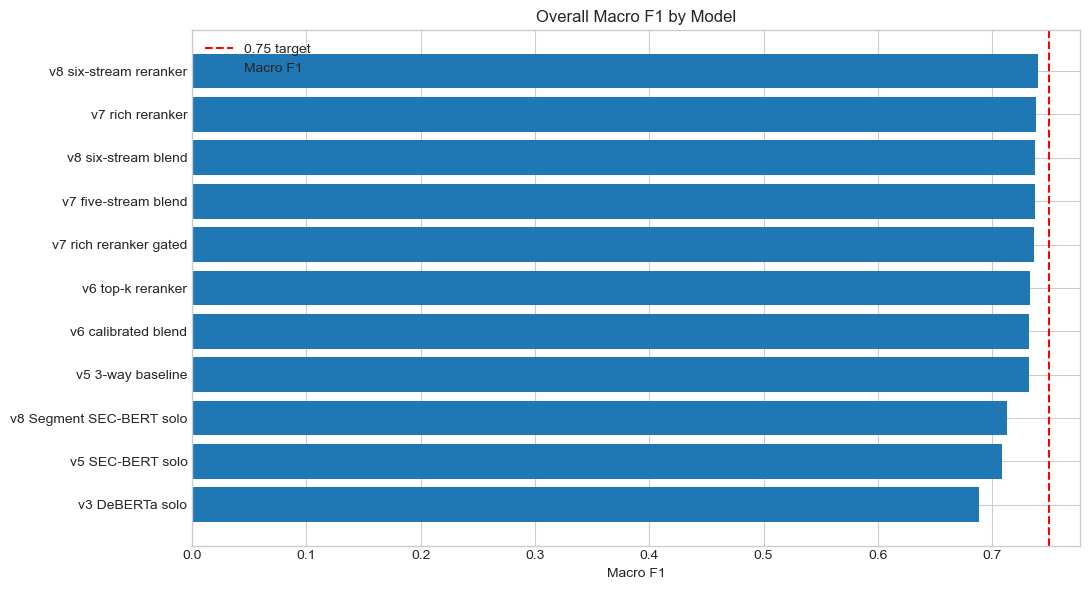

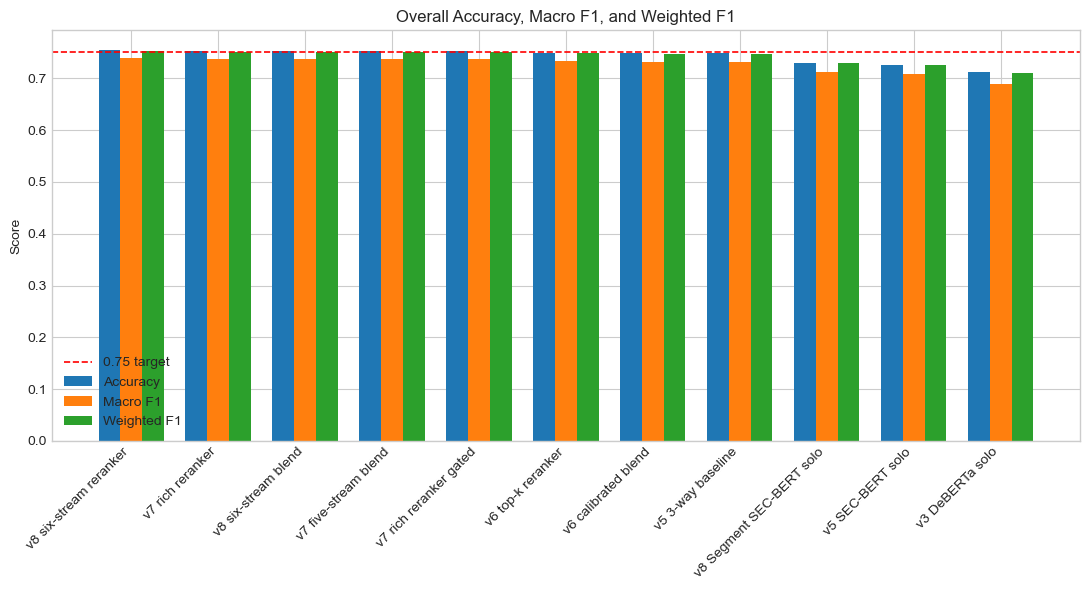

,model,top10_avg_f1,top10_min_f1,top10_avg_recall,top10_avg_precision,macro_f1
10,v8 six-stream reranker,0.7882,0.5831,0.7787,0.7998,0.7399
5,v7 five-stream blend,0.7877,0.5755,0.7860,0.7903,0.7372
6,v7 rich reranker,0.7872,0.5776,0.7747,0.8017,0.7381
7,v7 rich reranker gated,0.7872,0.5764,0.7840,0.7913,0.7370
9,v8 six-stream blend,0.7864,0.5789,0.7882,0.7855,0.7375
4,v6 top-k reranker,0.7856,0.5827,0.7731,0.8002,0.7332
1,v5 3-way baseline,0.7849,0.5747,0.7837,0.7871,0.7323
3,v6 calibrated blend,0.7846,0.5808,0.7836,0.7866,0.7324
8,v8 Segment SEC-BERT solo,0.7687,0.5805,0.7661,0.7724,0.7130
2,v5 SEC-BERT solo,0.7659,0.5402,0.7619,0.7716,0.7085


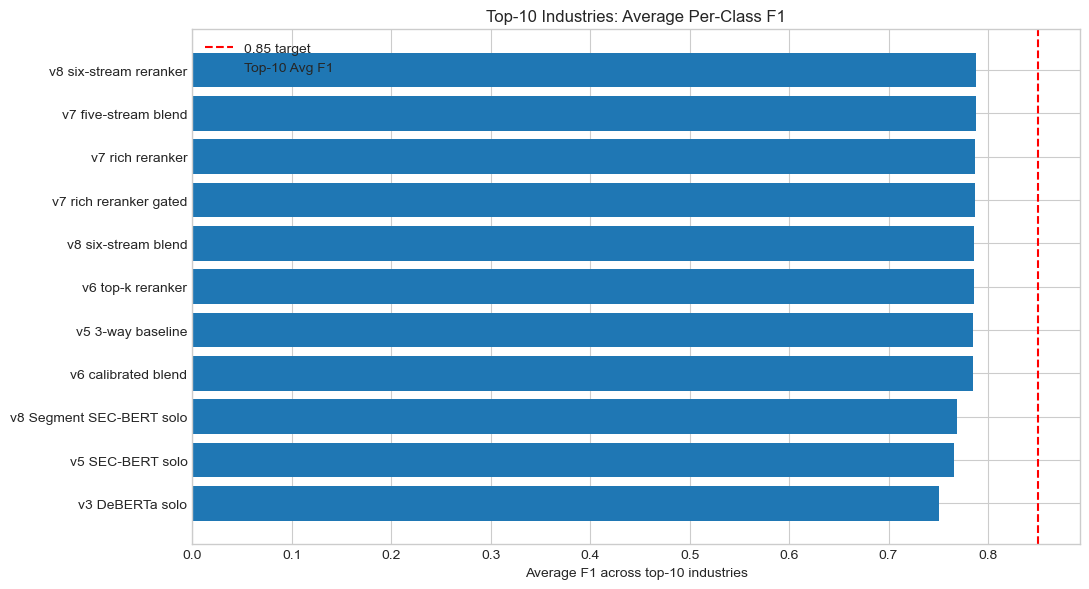

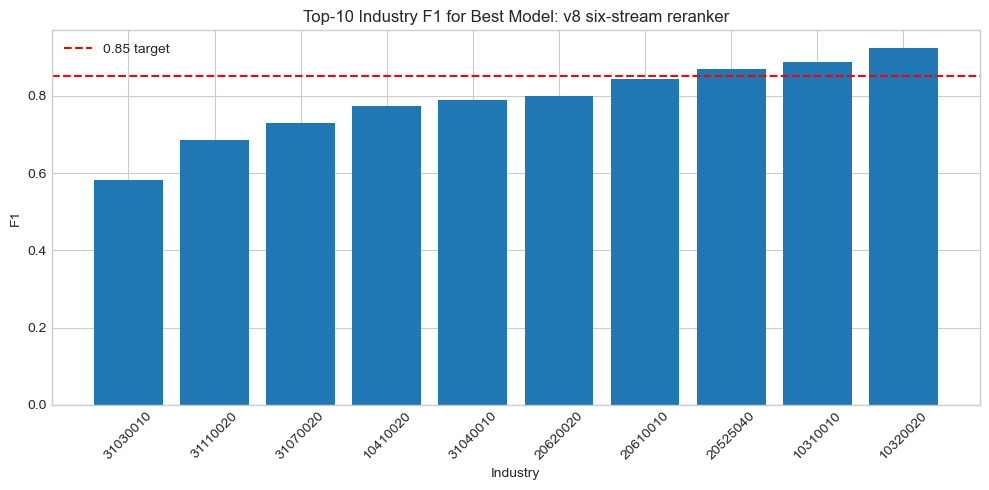

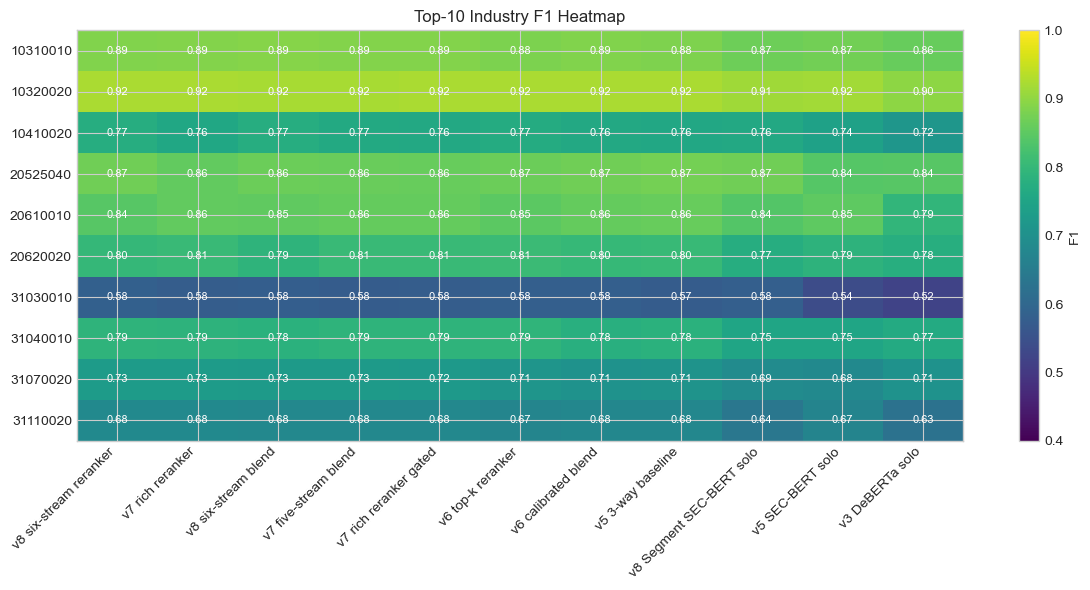

In [15]:
plt.style.use("seaborn-v0_8-whitegrid")

plot_df = metrics_df.sort_values("macro_f1", ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(plot_df["model"], plot_df["macro_f1"], label="Macro F1")
ax.axvline(0.75, color="red", linestyle="--", linewidth=1.5, label="0.75 target")
ax.set_title("Overall Macro F1 by Model")
ax.set_xlabel("Macro F1")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(metrics_df))
width = 0.25

ordered = metrics_df.sort_values("macro_f1", ascending=False).reset_index(drop=True)

ax.bar(x - width, ordered["accuracy"], width, label="Accuracy")
ax.bar(x, ordered["macro_f1"], width, label="Macro F1")
ax.bar(x + width, ordered["weighted_f1"], width, label="Weighted F1")

ax.axhline(0.75, color="red", linestyle="--", linewidth=1.2, label="0.75 target")
ax.set_title("Overall Accuracy, Macro F1, and Weighted F1")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(ordered["model"], rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

top10_summary = (
    top10_df
    .groupby("model", as_index=False)
    .agg(
        top10_avg_f1=("f1", "mean"),
        top10_min_f1=("f1", "min"),
        top10_avg_recall=("recall", "mean"),
        top10_avg_precision=("precision", "mean"),
    )
    .merge(metrics_df[["model", "macro_f1"]], on="model", how="left")
    .sort_values("top10_avg_f1", ascending=False)
)

display(top10_summary.style.format({
    "top10_avg_f1": "{:.4f}",
    "top10_min_f1": "{:.4f}",
    "top10_avg_recall": "{:.4f}",
    "top10_avg_precision": "{:.4f}",
    "macro_f1": "{:.4f}",
}))

fig, ax = plt.subplots(figsize=(11, 6))
plot_top10 = top10_summary.sort_values("top10_avg_f1", ascending=True)
ax.barh(plot_top10["model"], plot_top10["top10_avg_f1"], label="Top-10 Avg F1")
ax.axvline(0.85, color="red", linestyle="--", linewidth=1.5, label="0.85 target")
ax.set_title("Top-10 Industries: Average Per-Class F1")
ax.set_xlabel("Average F1 across top-10 industries")
ax.legend()
plt.tight_layout()
plt.show()

best_model = metrics_df.iloc[0]["model"]
best_top10 = top10_df[top10_df["model"] == best_model].sort_values("f1")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(best_top10["industry"], best_top10["f1"])
ax.axhline(0.85, color="red", linestyle="--", linewidth=1.5, label="0.85 target")
ax.set_title(f"Top-10 Industry F1 for Best Model: {best_model}")
ax.set_ylabel("F1")
ax.set_xlabel("Industry")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

heat = top10_df.pivot(index="industry", columns="model", values="f1")
heat = heat[metrics_df["model"].tolist()]

fig, ax = plt.subplots(figsize=(max(12, len(heat.columns) * 1.1), 6))
im = ax.imshow(heat.values, aspect="auto", cmap="viridis", vmin=0.4, vmax=1.0)

ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_title("Top-10 Industry F1 Heatmap")
fig.colorbar(im, ax=ax, label="F1")

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{heat.iloc[i, j]:.2f}", ha="center", va="center", color="white", fontsize=8)

plt.tight_layout()
plt.show()


In [16]:
from sklearn.metrics import f1_score, classification_report
import pandas as pd

top10 = df[TARGET_COL].value_counts().head(10).index.astype(str).tolist()

# choose your model prediction column
pred = pd.read_csv("models/task1_v8_test_predictions.csv")
y_true = pred["true"].astype(str)
y_pred = pred["six_stream_reranker_pred"].astype(str)

top10_macro_f1 = f1_score(
    y_true,
    y_pred,
    labels=top10,
    average="macro",
    zero_division=0
)

print(f"Top-10 industries macro F1: {top10_macro_f1:.4f}")

report = classification_report(
    y_true,
    y_pred,
    labels=top10,
    zero_division=0
)

print(report)


Top-10 industries macro F1: 0.7882
              precision    recall  f1-score   support

    10310010       0.92      0.86      0.89       354
    31030010       0.65      0.53      0.58       354
    10320020       0.91      0.94      0.92       325
    10410020       0.77      0.77      0.77       245
    31040010       0.80      0.78      0.79       204
    31070020       0.77      0.69      0.73       188
    31110020       0.68      0.68      0.68       184
    20525040       0.86      0.88      0.87       178
    20620020       0.80      0.80      0.80       174
    20610010       0.84      0.85      0.84       155

   micro avg       0.81      0.77      0.79      2361
   macro avg       0.80      0.78      0.79      2361
weighted avg       0.80      0.77      0.79      2361



In [17]:
# Industry distribution: count + percentage at all three hierarchy levels

# Leaf level (145 industries)
leaf_dist = df[TARGET_COL].value_counts()
leaf_pct = (leaf_dist / len(df) * 100).round(3)
leaf_df = pd.DataFrame({"count": leaf_dist, "percent": leaf_pct, "cumulative_pct": leaf_pct.cumsum().round(2)})
leaf_df.index.name = "MstarGlobal"

print(f"Total rows: {len(df):,}  |  Unique industries: {df[TARGET_COL].nunique()}")
print(f"Mean rows/industry: {len(df) / df[TARGET_COL].nunique():.1f}")
print(f"Median rows/industry: {int(leaf_dist.median())}")
print(f"Min: {leaf_dist.min()}  Max: {leaf_dist.max()}  (imbalance ratio: {leaf_dist.max()/leaf_dist.min():.1f}x)")

print("\n=== Top 20 industries (full leaf code) ===")
print(leaf_df.head(20).to_string())

print("\n=== Bottom 20 industries (rarest) ===")
print(leaf_df.tail(20).to_string())

# How many industries cover X% of the data
for cutoff in [25, 50, 75, 90, 95]:
    n_needed = (leaf_pct.cumsum() <= cutoff).sum() + 1
    print(f"  {n_needed:3d} industries cover {cutoff}% of rows")

# Sector level (first 3 digits, ~11 sectors)
print("\n=== Sector distribution (first 3 digits) ===")
sector_dist = df["sector"].value_counts() if "sector" in df.columns else df[TARGET_COL].str[:3].value_counts()
sector_pct = (sector_dist / len(df) * 100).round(2)
sector_df = pd.DataFrame({"count": sector_dist, "percent": sector_pct})
sector_df.index.name = "Sector"
print(sector_df.to_string())

# Group level (first 5 digits, ~55 groups)
print("\n=== Top 20 industry groups (first 5 digits) ===")
group_dist = df["group"].value_counts() if "group" in df.columns else df[TARGET_COL].str[:5].value_counts()
group_pct = (group_dist / len(df) * 100).round(3)
group_df = pd.DataFrame({"count": group_dist, "percent": group_pct})
group_df.index.name = "Group"
print(group_df.head(20).to_string())
print(f"\nTotal groups: {df['group'].nunique() if 'group' in df.columns else df[TARGET_COL].str[:5].nunique()}")

# Quick imbalance check: how skewed is the distribution?
total_industries = df[TARGET_COL].nunique()
print(f"\n=== Imbalance summary ===")
print(f"  Top 10% of industries ({total_industries // 10}) hold {leaf_pct.head(total_industries // 10).sum():.1f}% of all rows")
print(f"  Bottom 50% of industries ({total_industries // 2}) hold {leaf_pct.tail(total_industries // 2).sum():.1f}% of all rows")


Total rows: 53,585  |  Unique industries: 145
Mean rows/industry: 369.6
Median rows/industry: 231
Min: 28  Max: 2359  (imbalance ratio: 84.2x)

=== Top 20 industries (full leaf code) ===
             count  percent  cumulative_pct
MstarGlobal                                
10310010      2359    4.402            4.40
31030010      2358    4.400            8.80
10320020      2165    4.040           12.84
10410020      1632    3.046           15.89
31040010      1358    2.534           18.42
31070020      1250    2.333           20.75
31110020      1226    2.288           23.04
20525040      1185    2.211           25.25
20620020      1160    2.165           27.42
20610010      1036    1.933           29.35
31110010      1011    1.887           31.24
10130020       944    1.762           33.00
10410010       918    1.713           34.71
31110030       893    1.667           36.38
10200030       826    1.541           37.92
10330010       791    1.476           39.40
31020010       771   